## Baseline-Modell

# Erstellt je User einen Case/Trace mit den dazugehörigen Events (Zustandsverläufen).
# Insgesamt 3 Zustände möglich.
Ob die Patienten Tinnitus hatten oder nicht, wird noch nicht beachtet.

In [1]:
# Bibliotheken und Co laden
import pandas as pd
import numpy as np
from sklearn.impute import KNNImputer
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import RandomForestClassifier
import pm4py
from pm4py.objects.conversion.log import converter as log_converter
from pm4py.algo.filtering.log.variants import variants_filter
from scipy.stats import chi2_contingency
from scipy.stats import ttest_ind
import seaborn as sns

In [2]:
# CSV laden
df = pd.read_csv('/Users/elias/Desktop/Uni/4. Semester : Masterarbeit/2026-04-02 TYT_answers2.csv', sep=";")

# Überblick verschaffen

In [ ]:
df.head()

In [ ]:
df.info()

In [ ]:
df.describe(include="all")

In [ ]:
# Einzigartige Fälle
print("Anzahl Cases:", df["id"].nunique())

In [ ]:
# Einzigartige User
print("Anzahl User:", df["user_id"].nunique())

In [ ]:
# Einträge je User
print(f"Durchschnittliche Einträge pro User: {112184/3339:.2f}")

In [ ]:
# Fehlende Werte finden
df.isna().sum()

In [ ]:
# IDs finden, bei denen age fehlt
users_with_missing_age = df[df["age"].isna()]["user_id"].unique()

print(f"Anzahl User mit fehlendem Age: {len(users_with_missing_age)}")
print("User IDs:", users_with_missing_age)

In [ ]:
# IDs finden, bei denen gender fehlt
users_with_missing_gender = df[df["gender"].isna()]["user_id"].unique()

print(f"Anzahl User mit fehlendem Gender: {len(users_with_missing_gender)}")
print("User IDs:", users_with_missing_gender)

In [ ]:
# IDs finden, bei denen onset_duration fehlt
users_with_missing_onset_duration = df[df["onset_duration"].isna()]["user_id"].unique()

print(f"Anzahl User mit fehlendem onset_duration: {len(users_with_missing_onset_duration)}")
print("User IDs:", users_with_missing_onset_duration)

# Aufräumen

In [3]:
# Schauen, ob zwei Spalten redundante Inhalte haben
# bei True sind die Inhalte 1:1 gleich
df["created_at"].equals(df["updated_at"])

True

In [4]:
# Schauen, ob die Infos in der Spalte überhaupt relevant sind
df["user_agent"]

0         TrackYourTinnitus/1.1.1 (iPhone; iOS 7.1; Scal...
1         TrackYourTinnitus/1.1.1 (iPhone; iOS 7.1.1; Sc...
2         TrackYourTinnitus/1.1.2 (iPhone; iOS 7.1.1; Sc...
3         TrackYourTinnitus/1.1.2 (iPhone; iOS 7.1.1; Sc...
4         TrackYourTinnitus/1.1.2 (iPhone; iOS 7.1.1; Sc...
                                ...                        
112185    TrackYourTinnitus/1.2.1.1 (iPhone; iOS 16.3.1;...
112186    TrackYourTinnitus/1.2.1.1 (iPhone; iOS 16.7.5;...
112187    TrackYourTinnitus/1.2.1.1 (iPhone; iOS 17.4.1;...
112188    TrackYourTinnitus/1.2.1.1 (iPhone; iOS 17.5.1;...
112189    TrackYourTinnitus/1.2.1.1 (iPhone; iOS 17.5.1;...
Name: user_agent, Length: 112190, dtype: str

In [5]:
# Schauen, ob die Infos in der Spalte überhaupt relevant sind
df["autosaved"]

0         1
1         0
2         1
3         0
4         1
         ..
112185    0
112186    0
112187    0
112188    0
112189    0
Name: autosaved, Length: 112190, dtype: int64

In [6]:
# Spalten "user_agent", "updated_at" und "autosaved" entfernen.
# zudem "notification_fixed" und "notification_date" entfernen, da Miriam sie für unwichtig erklärt hat
df = df.drop(columns=["user_agent", "updated_at", "autosaved", "notification_fixed", "notification_date"])

In [7]:
# Wir werden Soundlevel selbst nochmal in auswertbare Werte zws den OS umwandeln.
# Daher könnten wir eigentlich "sound_env", "sound_env2" und "sound_rounded" entfernen.
df = df.drop(columns=["sound_env", "sound_env2", "sound_rounded"])

In [8]:
df.columns

Index(['id', 'q1', 'q2', 'q3', 'q4', 'q5', 'q6', 'q7', 'q8', 'soundlevel',
       'user_id', 'user_os', 'save_date', 'created_at', 'date_of_birth2',
       'age', 'famhistory', 'gender', 'handedness', 'onset_date2',
       'onset_duration'],
      dtype='str')

In [9]:
# Zeitspalten konvertieren
time_cols = ["save_date", "created_at"]
for col in time_cols:
    df[col] = pd.to_datetime(df[col], format="%d.%m.%y %H:%M", errors="coerce")

# Andere Zeitspalten konvertieren
date_cols = ["date_of_birth2", "onset_date2"]
for col in date_cols:
    df[col] = pd.to_datetime(df[col], format="%d.%m.%y", errors="coerce")

# Geschlecht & Alter (Missing Values Check & Vorbereitung)
# Erstellung einer Flag für fehlende demografische Daten, um später deren Einfluss prüfen zu können.
df["missing_demographics"] = df["gender"].isna() | df["age"].isna()

# Soundlevel nach OS trennen
# Erstellung zwei separater Spalten für die Sound-Umgebung (Skalen zsw. iOS und Android nicht direkt vergleichbar).
df["sound_ios"] = df.loc[df["user_os"] == "iOS", "soundlevel"]
df["sound_android"] = df.loc[df["user_os"] == "android", "soundlevel"]

# Normalisierung (Z-Transformation) pro OS, um eine einzige Spalte zu haben.
df["sound_norm"] = df.groupby("user_os")["soundlevel"].transform(
    lambda x: (x - x.mean()) / x.std() if x.std() != 0 else 0
)

# Zeitdifferenz (created_at)
# Zuerst nach User und Zeit sortieren, dann Differenz zum vorherigen Event berechnen.
df = df.sort_values(by=["user_id", "created_at"])
df["time_to_prev_event"] = df.groupby("user_id")["created_at"].diff().dt.days

In [10]:
print(df.groupby("user_os")["soundlevel"].describe())

           count         mean          std      min        25%       50%  \
user_os                                                                    
Android  60377.0  1561.787667  3144.501888    0.000    0.00000  330.0000   
iOS      49668.0  -344.829759   179.678665 -998.378 -484.00975 -381.4065   

            75%        max  
user_os                     
Android  1577.0  32124.000  
iOS      -120.0    -10.147  


In [11]:
print(df["time_to_prev_event"].mean())

2.8359684339142497


In [12]:
# Schauen, dass Werte von Q1-Q8 im erlaubten Bereich sind
# q1 und q8 (0 oder 1)
invalid_q1_q8 = df[
    (df["q1"] < 0) | (df["q1"] > 1) |
    (df["q8"] < 0) | (df["q8"] > 1)
]
print("q1/q8 Fehler:", len(invalid_q1_q8))

# q2 bis q7 (0–10)
invalid_q2_q7 = df[
    (df[["q2","q3","q4","q5","q6","q7"]] < 0).any(axis=1) |
    (df[["q2","q3","q4","q5","q6","q7"]] > 10).any(axis=1)
]
print("q2–q7 Fehler:", len(invalid_q2_q7))

q1/q8 Fehler: 0
q2–q7 Fehler: 0


In [13]:
# Schauen, dass "age" nicht <0 oder >110 ist
df["age"] = pd.to_numeric(df["age"], errors="coerce")
invalid_age = df[(df["age"] < 0) | (df["age"] > 110)]

print(invalid_age[["id", "user_id", "age"]])

          id  user_id    age
10948  12172      835  113.0


In [14]:
# Sicherstellen, dass "age" numerisch ist
df["age"] = pd.to_numeric(df["age"], errors="coerce")

# Alter und Onset_duration auf NaN setzen
df.loc[(df["user_id"] == 835) & ((df["age"] < 0) | (df["age"] > 110)), "age"] = pd.NA
df.loc[(df["user_id"] == 835), "onset_duration"] = pd.NA

# Kontrolle
df[df["user_id"] == 835]

,id,q1,q2,q3,q4,q5,q6,q7,q8,soundlevel,...,famhistory,gender,handedness,onset_date2,onset_duration,missing_demographics,sound_ios,sound_android,sound_norm,time_to_prev_event
10948,12172,1.0,9.0,10.0,0.0,0.0,9.0,5.0,1.0,909.0,...,0.0,0.0,2.0,2002-03-12,NaN,False,NaN,NaN,-0.207597,NaN


In [15]:
df.isna().sum()

id                           0
q1                        1625
q2                        1926
q3                        8021
q4                        2805
q5                        4415
q6                        9080
q7                        5333
q8                        3398
soundlevel                2145
user_id                      0
user_os                      0
save_date                  612
created_at                   0
date_of_birth2            4997
age                       5611
famhistory                2476
gender                    2549
handedness                2434
onset_date2               6021
onset_duration            1610
missing_demographics         0
sound_ios                62522
sound_android           112190
sound_norm                2145
time_to_prev_event        3339
dtype: int64

## Missing Data Strategie fahren

In [16]:
# für uns wäre es meiner Meinung nach wichtig, Missing Data bei q1-q8 zu korrigieren.
# am wichtigsten ist eigentlich q1. Wenn's nicht ausgefüllt ist, dann ... machen.

'''
# einfach ignorieren und somit nichts machen
'''

'''
# Löschen von Zeilen mit fehlenden q1 Werten
df = df.dropna(subset=["q1"])
'''

'''
# Fehlende q1 Werte mit -1 ersetzen. Später evtl. als eigene Gruppe analysierbar.
df["q1"] = df["q1"].fillna(-1).astype(int)
'''

'''
# Fehlende q1 Werte mit dem Mittelwert ersetzen
# Mittelwert berechnen und aufrunden
mean_val = df["q1"].mean()
rounded_val = int(np.ceil(mean_val)) # aus 0.80 wird 1
# Fehlende Werte ersetzen
df["q1"] = df["q1"].fillna(rounded_val)
print(f"Eingesetzter Mittelwert: {rounded_val}")
'''

'''
# Fehlende q1 Werte mit dem Median ersetzen
# Median berechnen
median_q1 = df["q1"].median()
# Fehlende Werte ersetzen
df["q1"] = df["q1"].fillna(median_q1)
print(f"Eingesetzter Median: {median_q1}")
'''

'''
# Fehlende q1 Werte mit kNN=5 ersetzen
# 1. Spalten auswählen, die für die Ähnlichkeit relevant sind
impute_cols = ["q1", "sound_env", "age", "gender"]

# Falls gender/sound_env Text sind, müssen sie in Zahlen umgewandelt werden (Faktorisiert)
df_impute = df[impute_cols].copy()

# Beispiel für kategorische Daten (falls nötig):
for col in df_impute.select_dtypes(include=['object']).columns:
    df_impute[col] = pd.factorize(df_impute[col])[0]

# 2. KNN Imputer konfigurieren (=5)
imputer = KNNImputer(n_neighbors=5)

# 3. Fehlende Werte schätzen
df_filled = imputer.fit_transform(df_impute)

# 4. Den Wert zurück in den originalen DataFrame schreiben
df["q1"] = df_filled[:, 0] # q1 ist die erste Spalte (Index 0)

# 5. Ergebnis auf 0 oder 1 runden
df["q1"] = df["q1"].round().astype(int)
'''

'\n# Fehlende q1 Werte mit kNN=5 ersetzen\n# 1. Spalten auswählen, die für die Ähnlichkeit relevant sind\nimpute_cols = ["q1", "sound_env", "age", "gender"]\n\n# Falls gender/sound_env Text sind, müssen sie in Zahlen umgewandelt werden (Faktorisiert)\ndf_impute = df[impute_cols].copy()\n\n# Beispiel für kategorische Daten (falls nötig):\nfor col in df_impute.select_dtypes(include=[\'object\']).columns:\n    df_impute[col] = pd.factorize(df_impute[col])[0]\n\n# 2. KNN Imputer konfigurieren (=5)\nimputer = KNNImputer(n_neighbors=5)\n\n# 3. Fehlende Werte schätzen\ndf_filled = imputer.fit_transform(df_impute)\n\n# 4. Den Wert zurück in den originalen DataFrame schreiben\ndf["q1"] = df_filled[:, 0] # q1 ist die erste Spalte (Index 0)\n\n# 5. Ergebnis auf 0 oder 1 runden\ndf["q1"] = df["q1"].round().astype(int)\n'

In [17]:
# Kontrolle ob q1 noch fehlende Werte hat
df.isna().sum()

id                           0
q1                        1625
q2                        1926
q3                        8021
q4                        2805
q5                        4415
q6                        9080
q7                        5333
q8                        3398
soundlevel                2145
user_id                      0
user_os                      0
save_date                  612
created_at                   0
date_of_birth2            4997
age                       5611
famhistory                2476
gender                    2549
handedness                2434
onset_date2               6021
onset_duration            1610
missing_demographics         0
sound_ios                62522
sound_android           112190
sound_norm                2145
time_to_prev_event        3339
dtype: int64

## User mit nur einem Eintrag entfernen

In [18]:
print(f"Anzahl einzigartiger Nutzer vor dem Entfernen: {df['user_id'].nunique()}")
# Behalte nur die user_id's, die mehr als einen Eintrag haben
df = df.groupby("user_id").filter(lambda x: len(x) > 1)

# Optional: Index zurücksetzen nach dem Löschen
#df = df.reset_index(drop=True)

# Kurze Kontrolle
print(f"Verbleibende Einträge: {len(df)}")
print(f"Anzahl einzigartiger Nutzer nach dem Entfernen: {df['user_id'].nunique()}")
print(f"Entfernte Nutzer: {3339-df['user_id'].nunique()}")

# Entfernte Nutzer in %
print(f"Entfernte Nutzer: {(1018/3339)*100:.2f}%")

Anzahl einzigartiger Nutzer vor dem Entfernen: 3339
Verbleibende Einträge: 111172
Anzahl einzigartiger Nutzer nach dem Entfernen: 2321
Entfernte Nutzer: 1018
Entfernte Nutzer: 30.49%


# Daten aufbereiten

In [19]:
df[df["created_at"].isna()]

,id,q1,q2,q3,q4,q5,q6,q7,q8,soundlevel,...,famhistory,gender,handedness,onset_date2,onset_duration,missing_demographics,sound_ios,sound_android,sound_norm,time_to_prev_event


In [20]:
df[df["save_date"].isna()]

,id,q1,q2,q3,q4,q5,q6,q7,q8,soundlevel,...,famhistory,gender,handedness,onset_date2,onset_duration,missing_demographics,sound_ios,sound_android,sound_norm,time_to_prev_event
2633,3189,0.0,8.0,4.0,4.0,5.0,2.0,9.0,1.0,NaN,...,0.0,0.0,1.0,NaT,#WERT!,False,NaN,NaN,NaN,NaN
2634,3190,1.0,7.0,5.0,NaN,NaN,NaN,NaN,0.0,-425.513,...,0.0,0.0,1.0,NaT,#WERT!,False,-425.513,NaN,-0.449042,0.0
2635,3191,1.0,6.0,4.0,4.0,NaN,NaN,NaN,0.0,NaN,...,0.0,0.0,1.0,NaT,#WERT!,False,NaN,NaN,NaN,0.0
2636,3192,1.0,5.0,2.0,4.0,5.0,2.0,7.0,1.0,-350.426,...,0.0,0.0,1.0,NaT,#WERT!,False,-350.426,NaN,-0.031146,0.0
2637,3193,1.0,6.0,5.0,4.0,NaN,NaN,NaN,0.0,-539.439,...,1.0,0.0,0.0,1995-03-07,#WERT!,False,-539.439,NaN,-1.083096,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
110295,110864,1.0,6.0,5.0,0.0,6.0,2.0,1.0,0.0,-522.364,...,0.0,1.0,2.0,2009-01-06,#WERT!,False,-522.364,NaN,-0.988065,0.0
110296,110865,1.0,6.0,5.0,0.0,6.0,2.0,1.0,0.0,-522.364,...,0.0,1.0,2.0,2009-01-06,#WERT!,False,-522.364,NaN,-0.988065,0.0
110297,110866,1.0,6.0,5.0,0.0,6.0,2.0,1.0,0.0,-522.364,...,0.0,1.0,2.0,2009-01-06,#WERT!,False,-522.364,NaN,-0.988065,0.0
110298,110867,1.0,6.0,5.0,0.0,6.0,2.0,1.0,0.0,-522.364,...,0.0,1.0,2.0,2009-01-06,#WERT!,False,-522.364,NaN,-0.988065,0.0


In [21]:
# Spalte "save_date" entfernen. Wir werden "created_at" als Zeitstempel nehmen
df = df.drop(columns=["save_date"])

In [22]:
# Änderungen kontrollieren
df.head()

,id,q1,q2,q3,q4,q5,q6,q7,q8,soundlevel,...,famhistory,gender,handedness,onset_date2,onset_duration,missing_demographics,sound_ios,sound_android,sound_norm,time_to_prev_event
0,2959,1.0,6.0,4.0,5.0,3.0,8.0,3.0,1.0,-688.462,...,0.0,0.0,0.0,2010-02-14,4,False,-688.462,NaN,-1.912482,NaN
1,2998,1.0,5.0,5.0,5.0,5.0,7.0,8.0,1.0,-109.410,...,0.0,0.0,0.0,2010-02-14,4,False,-109.410,NaN,1.310227,4.0
2,3002,0.0,NaN,NaN,1.0,NaN,NaN,NaN,1.0,-120.225,...,0.0,0.0,0.0,2010-02-14,4,False,-120.225,NaN,1.250036,1.0
3,3003,0.0,8.0,7.0,3.0,6.0,5.0,6.0,1.0,-394.602,...,0.0,0.0,0.0,2010-02-14,4,False,-394.602,NaN,-0.277007,0.0
4,3054,0.0,NaN,1.0,NaN,NaN,NaN,NaN,0.0,-187.568,...,0.0,0.0,0.0,2010-02-14,4,False,-187.568,NaN,0.875239,23.0


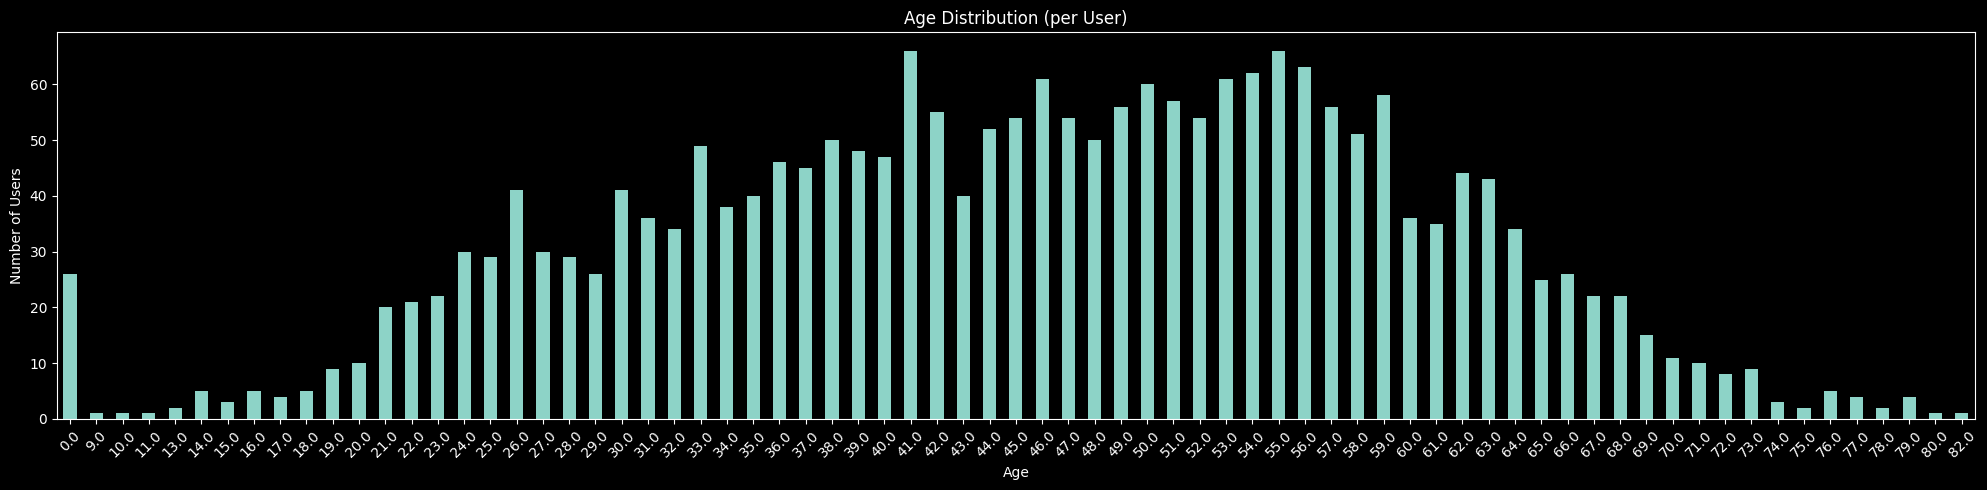

In [23]:
# pro User genau ein Eintrag (z. B. erster Eintrag)
df_user = df.drop_duplicates(subset="user_id")

plt.figure(figsize=(20,5))

df_user["age"].value_counts().sort_index().plot(kind="bar")

plt.title("Age Distribution (per User)")
plt.xlabel("Age")
plt.ylabel("Number of Users")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Einfluss verschiedener Faktoren auf *q1* Wert

## Vorbereitung

In [24]:
# Score berechnen (ohne q1, q4 und q8)
df["score"] = df[["q2","q3","q5","q6","q7"]].sum(axis=1)

# Kategorien definieren
def categorize(score):
    if score <= 17:
        return "low"
    elif score <= 34:
        return "medium"
    else:
        return "high"

df["concept:name"] = df["score"].apply(categorize)

In [25]:
# Fix für #ZAHL! bei onset_duration
# Alle nicht-numerischen Werte in onset_duration zu NaN machen
df["onset_duration"] = pd.to_numeric(df["onset_duration"], errors="coerce")

## Einfluss von Faktoren auf *q1*


--- Einfluss auf das Auftreten von Tinnitus (q1=1) ---
              Feature  Gewichtung
0                  q1    0.368799
2          sound_norm    0.250768
1               score    0.137681
3                 age    0.120307
4      onset_duration    0.091737
5  time_to_prev_event    0.030709


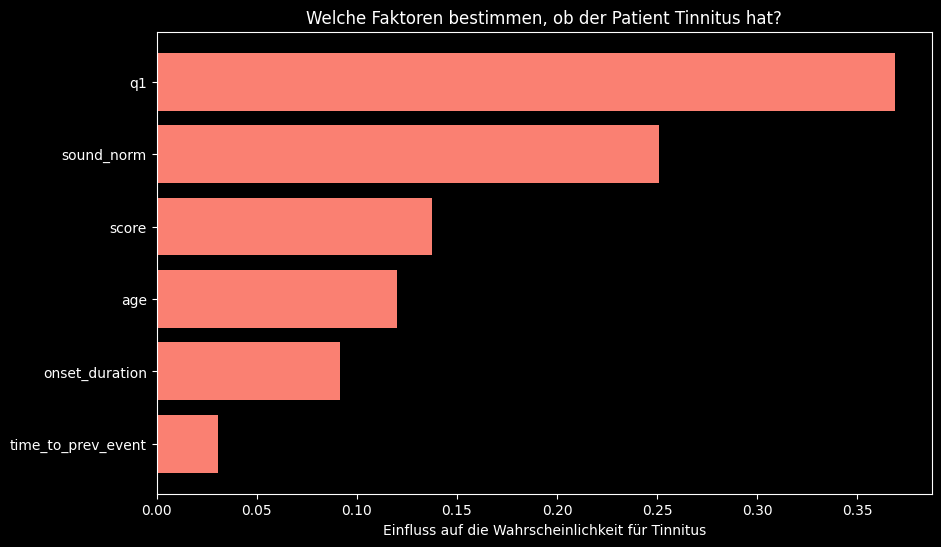

In [31]:
## Klassifikations-Analyse: Was beeinflusst das Tinnitus-Auftreten (q1)?
# 1. Daten vorbereiten
# Wir wollen vorhersagen, ob q1 beim NÄCHSTEN Termin '1' ist (Tinnitus vorhanden)
df['next_q1'] = df.groupby('user_id')['q1'].shift(-1)

# Features: Wir nutzen den Score, Sound, Alter, etc. von HEUTE
features_clf = ["q1", "score", "sound_norm", "age", "onset_duration", "time_to_prev_event"]
target_clf = "next_q1"

# Daten bereinigen (nur vollständige Zeilen für Klassifikation)
df_clf = df[features_clf + [target_clf]].dropna()
X_clf = df_clf[features_clf]
y_clf = df_clf[target_clf].astype(int)  # Sicherstellen, dass es 0 oder 1 ist

# 2. Random Forest Classifier trainieren
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_clf, y_clf)

# 3. Einflussfaktoren (Feature Importance)
importances_clf = pd.DataFrame({
    "Feature": features_clf,
    "Gewichtung": clf.feature_importances_
}).sort_values(by="Gewichtung", ascending=False)

print("\n--- Einfluss auf das Auftreten von Tinnitus (q1=1) ---")
print(importances_clf)

# 4. Visualisierung der Einflussfaktoren
plt.figure(figsize=(10, 6))
plt.barh(importances_clf["Feature"], importances_clf["Gewichtung"], color="salmon")
plt.xlabel("Einfluss auf die Wahrscheinlichkeit für Tinnitus")
plt.title("Welche Faktoren bestimmen, ob der Patient Tinnitus hat?")
plt.gca().invert_yaxis()
plt.show()

### Einfluss von *q1* auf *q1*

In [27]:
# Wahrscheinlichkeiten berechnen

# 1. Wir betrachten nur die Fälle, bei denen wir den Vorher-Nachher-Status kennen
df_q1_analysis = df.dropna(subset=['q1', 'next_q1']).copy()

# 2. Wahrscheinlichkeit für Tinnitus im nächsten Eintrag, gegeben der aktuelle Status (q1)
# Wir teilen die Daten in: Heute Tinnitus (q1=1) und Heute kein Tinnitus (q1=0)
status_0 = df_q1_analysis[df_q1_analysis['q1'] == 0]
status_1 = df_q1_analysis[df_q1_analysis['q1'] == 1]

prob_tinnitus_from_0 = status_0['next_q1'].mean() * 100
prob_tinnitus_from_1 = status_1['next_q1'].mean() * 100

print(f"--- Tinnitus-Verlaufs-Analyse ---")
print(f"Wahrscheinlichkeit für Tinnitus-Auftreten (q1=0 -> q1=1): {prob_tinnitus_from_0:.2f}%")
print(f"Wahrscheinlichkeit für Tinnitus-Persistenz (q1=1 -> q1=1): {prob_tinnitus_from_1:.2f}%")
print(f"\nAnzahl untersuchter Fälle (q1=0): {len(status_0)}")
print(f"Anzahl untersuchter Fälle (q1=1): {len(status_1)}")

# 3. Zum Vergleich: Der "Lift" durch Tinnitus heute
# Wie viel wahrscheinlicher ist Tinnitus morgen, wenn ich heute schon welchen habe?
lift = prob_tinnitus_from_1 / prob_tinnitus_from_0
print(f"\nDer Patient ist beim heutigen Tinnitus-Status '= 1' {lift:.2f}-mal wahrscheinlicher morgen wieder betroffen.")

--- Tinnitus-Verlaufs-Analyse ---
Wahrscheinlichkeit für Tinnitus-Auftreten (q1=0 -> q1=1): 28.64%
Wahrscheinlichkeit für Tinnitus-Persistenz (q1=1 -> q1=1): 92.68%

Anzahl untersuchter Fälle (q1=0): 21368
Anzahl untersuchter Fälle (q1=1): 85494

Der Patient ist beim heutigen Tinnitus-Status '= 1' 3.24-mal wahrscheinlicher morgen wieder betroffen.


In [28]:
# Signifikanz berechnen

# 1. Kontingenztabelle erstellen
# Zeilen: Status Heute (q1=0 oder 1), Spalten: Status Morgen (next_q1=0 oder 1)
contingency_table_q1 = pd.crosstab(
    df_q1_analysis['q1'],
    df_q1_analysis['next_q1']
)

print("\n--- Kontingenztabelle: q1 Heute vs. next_q1 Morgen ---")
print(contingency_table_q1)

# 2. Chi-Quadrat-Test
chi2, p_val, dof, expected = chi2_contingency(contingency_table_q1)

print(f"\n--- Signifikanz-Analyse: Tinnitus-Persistenz ---")
print(f"Chi-Quadrat: {chi2:.2f}")
print(f"p-Wert: {p_val:.4e}") # wissenschaftliche Notation, da extrem klein

if p_val < 0.05:
    print("Ergebnis: Statistisch hochsignifikant (Der Status heute bestimmt den Status morgen).")
else:
    print("Ergebnis: Nicht signifikant.")


--- Kontingenztabelle: q1 Heute vs. next_q1 Morgen ---
next_q1    0.0    1.0
q1                   
0.0      15248   6120
1.0       6262  79232

--- Signifikanz-Analyse: Tinnitus-Persistenz ---
Chi-Quadrat: 43597.12
p-Wert: 0.0000e+00
Ergebnis: Statistisch hochsignifikant (Der Status heute bestimmt den Status morgen).


### Einfluss von *Lärm* auf *q1*
Lärm = noise_burst_cases

In [84]:
# Wahrscheinlichkeiten berechnen

# 1. Tinnitus-Veränderung (Delta q1)
# q1 ist binär (0 oder 1). Wenn q1 von 0 auf 1 wechselt, ist das eine Verschlechterung.
df['delta_q1'] = df.groupby('user_id')['q1'].diff()
df['next_delta_q1'] = df.groupby('user_id')['delta_q1'].shift(-1)

# 2. Analyse: Wie oft entsteht Tinnitus (q1=1) nach einer Lärm-Verschlechterung?
# Wir schauen uns nur Fälle an, wo es vorher KEIN Tinnitus gab (q1=0)
no_tinnitus_before = df[df['q1'] == 0].copy()
noise_burst_cases = no_tinnitus_before[no_tinnitus_before['after_noise_burst'] == True]

# Berechne den Anteil der Fälle, in denen Tinnitus beim nächsten Event auftrat
tinnitus_onset_rate = noise_burst_cases['next_q1'].mean() * 100

print(f"--- Tinnitus-Auftreten-Analyse nach Lärm ---")
print(f"Wahrscheinlichkeit für Tinnitus-Auftreten nach Lärm (bei Patienten ohne Tinnitus): {tinnitus_onset_rate:.2f}%")
print(f"Anzahl untersuchter Fälle: {len(noise_burst_cases)}")

--- Tinnitus-Auftreten-Analyse nach Lärm ---
Wahrscheinlichkeit für Tinnitus-Auftreten nach Lärm (bei Patienten ohne Tinnitus): 27.16%
Anzahl untersuchter Fälle: 3449


In [83]:
# Signifikanz berechnen

# 1. Daten filtern: Nur Fälle, in denen vorher KEIN Tinnitus (q1=0) vorlag
df_no_tinnitus = df[df['q1'] == 0].copy()

# 2. Kontingenztabelle erstellen
# Zeilen: Lärm-Ereignis (Ja/Nein), Spalten: Tinnitus-Status beim nächsten Eintrag (0/1)
# Wir nutzen next_q1, das wir es vorher definiert haben
contingency_table_tinnitus = pd.crosstab(
    df_no_tinnitus['after_noise_burst'],
    df_no_tinnitus['next_q1']
)

print("\n--- Kontingenztabelle: Lärm vs. Tinnitus-Auftreten ---")
print(contingency_table_tinnitus)

# 3. Chi-Quadrat-Test
chi2, p_value, dof, expected = chi2_contingency(contingency_table_tinnitus)

print(f"\n--- Signifikanz-Analyse: Lärm -> Tinnitus-Auftreten ---")
print(f"Chi-Quadrat: {chi2:.2f}")
print(f"p-Wert: {p_value:.4f}")

if p_value < 0.05:
    print("Ergebnis: Signifikanter Zusammenhang zwischen Lärm und Tinnitus-Auftreten.")
else:
    print("Ergebnis: Kein signifikanter Zusammenhang nachweisbar.")


--- Kontingenztabelle: Lärm vs. Tinnitus-Auftreten ---
next_q1              0.0   1.0
after_noise_burst             
False              12797  5206
True                2451   914

--- Signifikanz-Analyse: Lärm -> Tinnitus-Auftreten ---
Chi-Quadrat: 4.19
p-Wert: 0.0407
Ergebnis: Signifikanter Zusammenhang zwischen Lärm und Tinnitus-Auftreten.


In [ ]:
# Ohne Lärm (False): Von 18.003 Fällen (12.797 + 5.206) traten bei 5.206 Tinnitus auf. Das entspricht einer Quote von ca. 28,9 %.
# Mit Lärm (True): Von 3.365 Fällen (2.451 + 914) traten bei 914 Tinnitus auf. Das entspricht einer Quote von ca. 27,2 %.

# Tinnitus-Rate mit Lärm (27,2%) niedriger als Tinnitus-Rate ohne Lärm (28,9%).

# Mögliche Interpretation:
# Der Chi-Quadrat-Test bestätigt einen signifikanten Zusammenhang zwischen Lärmexposition und dem Tinnitus-Auftreten (p=0,0407).
# Auffällig ist jedoch, dass die Tinnitus-Inzidenz nach Lärm-Events deskriptiv leicht unter dem Durchschnitt der Phasen ohne Lärm liegt.
# Dies könnte darauf hindeuten, dass Lärm nicht in jedem Fall Tinnitus auslöst, sondern möglicherweise auch durch Maskierungseffekte (Background-Noise)
# zu einer kurzfristigen subjektiven Linderung führt.
# Der signifikante p-Wert deutet darauf hin, dass die akustische Umwelt den Tinnitus-Status des Patienten dennoch deterministisch beeinflusst
# – die Richtung des Effekts (Verschlechterung vs. Maskierung) scheint jedoch inter-individuell zu variieren.

In [85]:
# den Part würde ich eher vernachlässigen /rausschmeißen

# Wahrscheinlichkeit berechnen (frische und chronische Patienten)

# Vergleich der Auftrete-Rate zwischen 'Frisch' und 'Chronisch'
onset_median = df['onset_duration'].median()

fresh_patients = noise_burst_cases[noise_burst_cases['onset_duration'] <= onset_median]
chronic_patients = noise_burst_cases[noise_burst_cases['onset_duration'] > onset_median]

print(f"\n--- Vergleich: Tinnitus-Auftreten nach Lärm ---")
print(f"Tinnitus-Auftreten bei 'frischen' Fällen: {(fresh_patients['next_q1'].mean() * 100):.2f}%")
print(f"Tinnitus-Auftreten bei 'chronischen' Fällen: {(chronic_patients['next_q1'].mean() * 100):.2f}%")


--- Vergleich: Tinnitus-Auftreten nach Lärm ---
Tinnitus-Auftreten bei 'frischen' Fällen: 34.80%
Tinnitus-Auftreten bei 'chronischen' Fällen: 26.45%


In [82]:
# den Part würde ich eher vernachlässigen /rausschmeißen

# Signifikanz berechnen (frische und chronische Patienten)

# 1. Kontingenztabelle erstellen
# Wir bauen eine Tabelle: [Tinnitus=0, Tinnitus=1] für [Frisch, Chronisch]
contingency_table = pd.crosstab(
    index=pd.concat([fresh_patients['next_q1'], chronic_patients['next_q1']]),
    columns=[['Frisch']*len(fresh_patients) + ['Chronisch']*len(chronic_patients)]
).T

# Falls die Tabelle die falsche Form hat (Rows/Cols), korrigieren wir sie kurz:
# Spalten: Tinnitus=0, Tinnitus=1; Zeilen: Gruppe
tab = pd.DataFrame({
    'No_Tinnitus': [len(fresh_patients[fresh_patients['next_q1']==0]), len(chronic_patients[chronic_patients['next_q1']==0])],
    'Tinnitus': [len(fresh_patients[fresh_patients['next_q1']==1]), len(chronic_patients[chronic_patients['next_q1']==1])]
}, index=['Frisch', 'Chronisch'])

print(contingency_table)

# 2. Chi-Quadrat-Test
chi2, p_val, dof, expected = chi2_contingency(tab)

print(f"\n--- Korrekte Signifikanz-Analyse (Chi-Quadrat) ---")
print(f"p-Wert: {p_val:.4f}")

if p_val < 0.05:
    print("Ergebnis: Statistisch signifikant (Die Gruppen reagieren unterschiedlich).")
else:
    print("Ergebnis: Nicht signifikant (Der Unterschied ist zufällig).")

next_q1     0.0  1.0
col_0               
Chronisch   787  283
Frisch     1064  568

--- Korrekte Signifikanz-Analyse (Chi-Quadrat) ---
p-Wert: 0.0000
Ergebnis: Statistisch signifikant (Die Gruppen reagieren unterschiedlich).


In [ ]:
# Es gibt einen stark signifikanten Zusammenhang zwischen der Erkrankungsdauer (frisch vs. chronisch) und der Wahrscheinlichkeit,
# nach einer Lärmexposition einen Tinnitus-Auftreten zu erleben.

### Einfluss von *score* auf *q1*

In [89]:
# Wahrscheinlichkeiten berechnen

df_clf['score_bins'] = pd.cut(df_clf['score'], bins=[0, 17, 34, 50], labels=["low", "medium", "high"])
prob_table = df_clf.groupby('score_bins', observed=True)['next_q1'].mean() * 100

print("\n--- Wahrscheinlichkeit für Tinnitus-Auftreten je Score-Level ---")
print(prob_table.map("{:.2f}%".format))


--- Wahrscheinlichkeit für Tinnitus-Auftreten je Score-Level ---
score_bins
low       72.38%
medium    88.45%
high      93.93%
Name: next_q1, dtype: str


In [90]:
# 1. Kontingenztabelle für Score-Level vs. Tinnitus-Auftreten (next_q1)
contingency_table_score = pd.crosstab(
    df_clf['score_bins'],
    df_clf['next_q1']
)

print("\n--- Kontingenztabelle: Score-Level vs. Tinnitus-Auftreten (next_q1) ---")
print(contingency_table_score)

# 2. Chi-Quadrat-Test
from scipy.stats import chi2_contingency
chi2, p_val, dof, expected = chi2_contingency(contingency_table_score)

print(f"\n--- Signifikanz-Analyse: Score-Einfluss ---")
print(f"Chi-Quadrat: {chi2:.2f}")
print(f"p-Wert: {p_val:.4e}")

if p_val < 0.05:
    print("Ergebnis: Statistisch hochsignifikant (Der Score-Level beeinflusst das Tinnitus-Risiko am nächsten Tag).")
else:
    print("Ergebnis: Nicht signifikant.")


--- Kontingenztabelle: Score-Level vs. Tinnitus-Auftreten (next_q1) ---
next_q1       0.0    1.0
score_bins              
low         11288  29575
medium       5799  44399
high          258   3994

--- Signifikanz-Analyse: Score-Einfluss ---
Chi-Quadrat: 4348.54
p-Wert: 0.0000e+00
Ergebnis: Statistisch hochsignifikant (Der Score-Level beeinflusst das Tinnitus-Risiko am nächsten Tag).


In [ ]:
# Low: 29.575/(11.288+29.575)≈72,4% Risiko für Tinnitus-Auftreten.
# Medium: 44.399/(5.799+44.399)≈88,4% Risiko für Tinnitus-Auftreten.
# High: 3.994/(258+3.994)≈93,9% Risiko für Tinnitus-Auftreten.

# Feature Engineering und statistische Analyse

In [34]:
# Score berechnen (ohne q1, q4 und q8)
df["score"] = df[["q2","q3","q5","q6","q7"]].sum(axis=1)

# Kategorien definieren
def categorize(score):
    if score <= 17:
        return "low"
    elif score <= 34:
        return "medium"
    else:
        return "high"

df["concept:name"] = df["score"].apply(categorize)

/var/folders/v4/h_gft9sn0j7_2h1tpqzxsmy40000gn/T/ipykernel_21825/958056254.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="concept:name", order=level_order, palette="viridis")


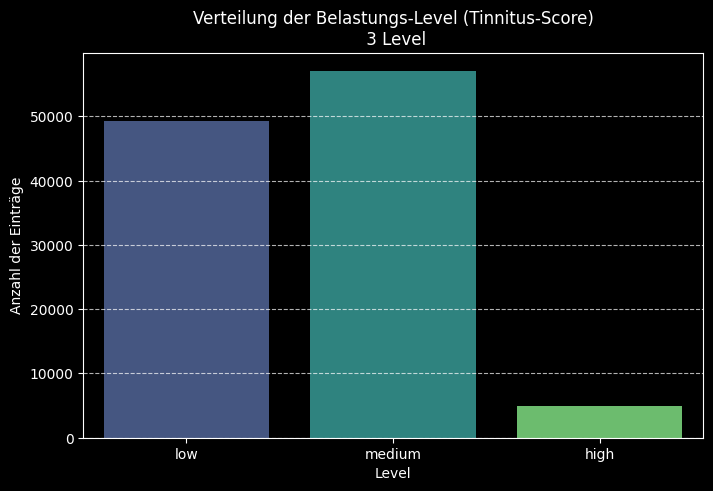

In [35]:
# Verteilung der Level visualisieren
plt.figure(figsize=(8, 5))

# Wir nutzen seaborn für eine schöne Darstellung
# Die Reihenfolge der Balken bestimmen wir manuell für eine logische Abfolge
level_order = ["low", "medium", "high"]

sns.countplot(data=df, x="concept:name", order=level_order, palette="viridis")

plt.title("Verteilung der Belastungs-Level (Tinnitus-Score)\n 3 Level")
plt.xlabel("Level")
plt.ylabel("Anzahl der Einträge")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [36]:
# Berechnung der Prozentwerte
dist = df["concept:name"].value_counts(normalize=True).reindex(level_order) * 100

print("--- Prozentuale Verteilung der Level ---")
print(dist.map("{:.1f}%".format))

--- Prozentuale Verteilung der Level ---
concept:name
low       44.3%
medium    51.3%
high       4.4%
Name: proportion, dtype: str


In [37]:
# Fix für #ZAHL! bei onset_duration
# Alle nicht-numerischen Werte in onset_duration zu NaN machen
df["onset_duration"] = pd.to_numeric(df["onset_duration"], errors="coerce")

# Nur relevante Spalten für die Analyse auswählen
features = [
    "age", "q1", "time_to_prev_event",
    "sound_norm", "missing_demographics", "onset_duration"
]

# Zielvariable (der aktuelle Score)
target = "score"

# Daten bereinigen: Nur Zeilen ohne NaNs in diesen Spalten nutzen
analysis_df = df[features + [target]].dropna()

# Falls user_OS noch ein String ist, für die Analyse in Zahlen umwandeln
# analysis_df["user_OS_coded"] = pd.factorize(df["user_OS"])[0]

In [38]:
df.info()

<class 'pandas.DataFrame'>
Index: 111172 entries, 0 to 112189
Data columns (total 30 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   id                    111172 non-null  int64         
 1   q1                    109557 non-null  float64       
 2   q2                    109274 non-null  float64       
 3   q3                    103199 non-null  float64       
 4   q4                    108385 non-null  float64       
 5   q5                    106783 non-null  float64       
 6   q6                    102145 non-null  float64       
 7   q7                    105876 non-null  float64       
 8   q8                    107821 non-null  float64       
 9   soundlevel            109028 non-null  float64       
 10  user_id               111172 non-null  int64         
 11  user_os               111172 non-null  str           
 12  created_at            111172 non-null  datetime64[us]
 13  date_of_birth2 

In [39]:
analysis_df
analysis_df.info()

<class 'pandas.DataFrame'>
Index: 98804 entries, 1 to 112189
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   age                   98804 non-null  float64
 1   q1                    98804 non-null  float64
 2   time_to_prev_event    98804 non-null  float64
 3   sound_norm            98804 non-null  float64
 4   missing_demographics  98804 non-null  bool   
 5   onset_duration        98804 non-null  float64
 6   score                 98804 non-null  float64
dtypes: bool(1), float64(6)
memory usage: 5.4 MB



--- Statistische Gewichtung der Features ---
                Feature  Gewichtung
2            prev_score    0.601911
3            sound_norm    0.170802
0                   age    0.094328
4        onset_duration    0.077331
6    time_to_prev_event    0.033049
5                    q1    0.022108
1  missing_demographics    0.000472


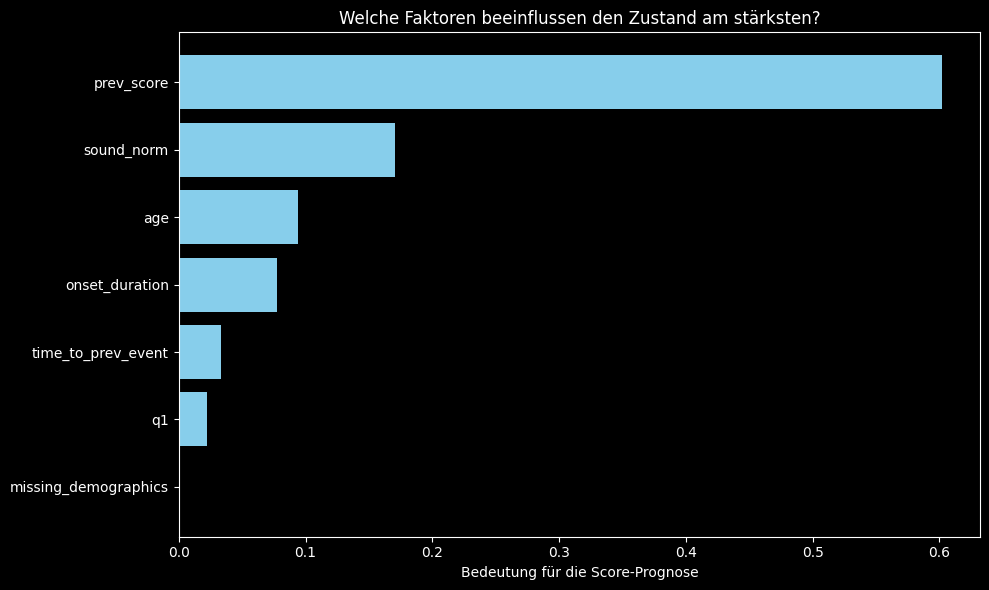

In [40]:
# Modell trainieren, um Stärke der Einflussfaktoren zu identifizieren.
# Neue Variante / neu hinzugefügt

# 1. Daten vorbereiten
df['prev_score'] = df.groupby('user_id')['score'].shift(1)
features_new = ["age", "missing_demographics", "prev_score", "sound_norm", "onset_duration", "q1", "time_to_prev_event"]
target = "score"

# Daten bereinigen
df_clean = df[features_new + [target]].dropna()
X = df_clean[features_new]
y = df_clean[target]

# 2. Modell definieren und trainieren
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X, y)

# 3. Gewichte extrahieren
importances = pd.DataFrame({
    "Feature": features_new,
    "Gewichtung": model.feature_importances_
}).sort_values(by="Gewichtung", ascending=False)

print("\n--- Statistische Gewichtung der Features ---")
print(importances)

# 4. Grafik ausgeben
plt.figure(figsize=(10, 6))
plt.barh(importances["Feature"], importances["Gewichtung"], color="skyblue")
plt.xlabel("Bedeutung für die Score-Prognose")
plt.title("Welche Faktoren beeinflussen den Zustand am stärksten?")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [41]:
# prev_score zeigt, dass ohne ihn der Score im kommenden Event 60,2% schlechter vorhergesagt werden könnte.
# sound_norm zeigt, dass ohne ihn der Score im kommenden Event 17,1% schlechter vorhergesagt werden könnte.

# --> ist der prev_score wirklich der Grund für den kommenden Score? Oder ist es eher sound_norm? Man könnte sagen, das die Lösung darin liegt, den Score zu reduzieren.

In [42]:
# Modell trainieren, um Stärke der Einflussfaktoren zu identifizieren.

# Modell definieren
model = RandomForestRegressor(n_estimators=100, random_state=42)

# Training
X = analysis_df[features]
y = analysis_df[target]
model.fit(X, y)

# Gewichte extrahieren
importances = pd.DataFrame({
    "Feature": features,
    "Gewichtung": model.feature_importances_
}).sort_values(by="Gewichtung", ascending=False)

print("\n--- Statistische Gewichtung der Features ---")
print(importances)


--- Statistische Gewichtung der Features ---
                Feature  Gewichtung
3            sound_norm    0.368683
0                   age    0.254935
5        onset_duration    0.230343
1                    q1    0.094475
2    time_to_prev_event    0.051196
4  missing_demographics    0.000369


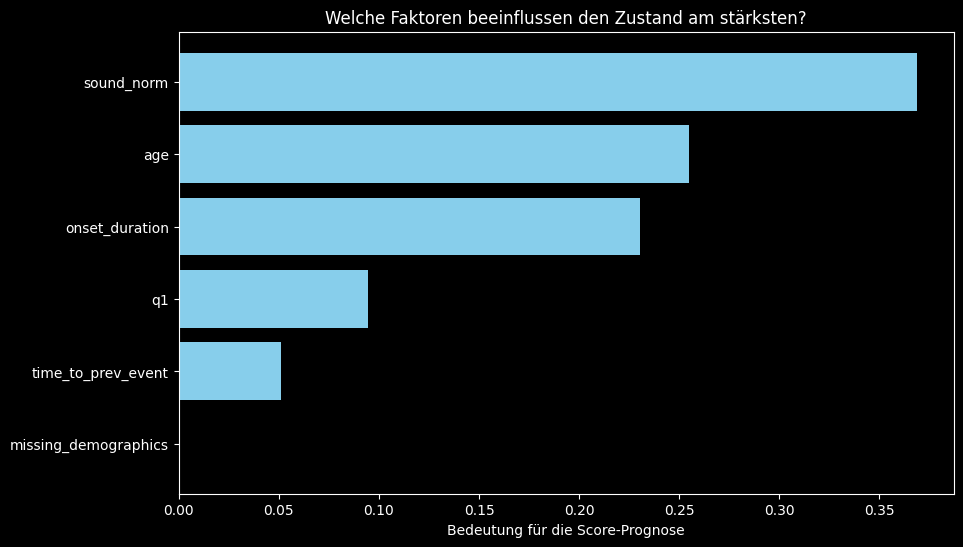

In [43]:
plt.figure(figsize=(10, 6))
plt.barh(importances["Feature"], importances["Gewichtung"], color="skyblue")
plt.xlabel("Bedeutung für die Score-Prognose")
plt.title("Welche Faktoren beeinflussen den Zustand am stärksten?")
plt.gca().invert_yaxis()
plt.show()

In [44]:
# --> missing_demographics hat keinen Einfluss. Könnte man auch von Beginn an rausnehmen.

# sound_norm zeigt, dass ohne ihn der Score im kommenden Event 36,9% schlechter vorhergesagt werden könnte.

In [45]:
# Prüfe die Korrelation zwischen Sound und Score im Detail
print(f"Korrelation Sound/Score: {analysis_df['sound_norm'].corr(analysis_df['score']):.3f}")

# Schau dir den durchschnittlichen Score in Sound-Quantilen an
analysis_df['sound_bins'] = pd.qcut(analysis_df['sound_norm'], q=5)
print(analysis_df.groupby('sound_bins')[target].mean())

Korrelation Sound/Score: 0.035
sound_bins
(-3.638, -0.497]    18.093583
(-0.497, -0.444]    19.987710
(-0.444, -0.186]    19.444321
(-0.186, 0.626]     19.377967
(0.626, 9.719]      19.145489
Name: score, dtype: float64


--- Schwellenwert Analyse: Sound vs. Score ---
         sound_bins      score
0  (-3.638, -0.831]  18.847473
1  (-0.831, -0.497]  17.828829
2  (-0.497, -0.444]  20.149347
3   (-0.444, -0.35]  19.607064
4   (-0.35, -0.177]  19.245529
5   (-0.177, 0.102]  19.301688
6    (0.102, 0.675]  19.326149
7    (0.675, 1.251]  18.011863
8    (1.251, 9.719]  19.830172


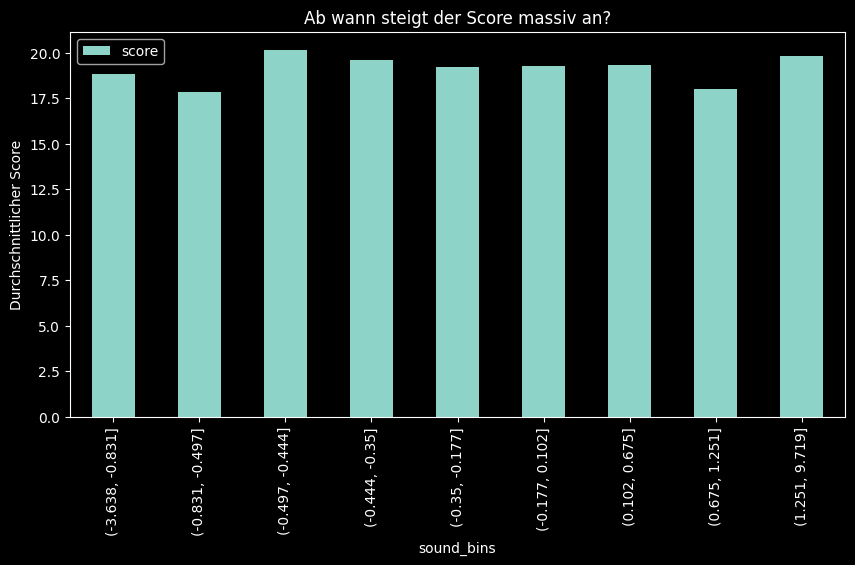

In [46]:
# Sound-Daten in 10 gleich große Gruppen unterteilen (Dezile)
df['sound_bins'] = pd.qcut(df['sound_norm'], q=10, duplicates='drop')

# Durchschnittlichen Score pro Gruppe berechnen
threshold_analysis = df.groupby('sound_bins', observed=True)['score'].mean().reset_index()

print("--- Schwellenwert Analyse: Sound vs. Score ---")
print(threshold_analysis)

# Visualisierung
threshold_analysis.plot(kind='bar', x='sound_bins', y='score', figsize=(10,5))
plt.title("Ab wann steigt der Score massiv an?")
plt.ylabel("Durchschnittlicher Score")
plt.show()

In [47]:
# 1. Veränderungen berechnen (Delta)
df = df.sort_values(by=["user_id", "created_at"])
df['delta_sound'] = df.groupby('user_id')['sound_norm'].diff()
df['delta_score'] = df.groupby('user_id')['score'].diff()

# 2. Den nächsten Score-Schritt an die aktuelle Zeile ziehen (Shift -1)
# Wir wollen wissen: Wenn Sound JETZT steigt, was macht der Score beim NÄCHSTEN Mal?
df['next_delta_score'] = df.groupby('user_id')['delta_score'].shift(-1)

# 3. Zeitabstand zum nächsten Event berechnen
df['days_to_next'] = df.groupby('user_id')['time_to_prev_event'].shift(-1)

# 4. Filter: Nur Fälle, in denen sich der Sound signifikant verschlechtert hat (z.B. Delta > 0.5. Kann aber auch 0.3 oder 0.7 sein)
deterioration = df[df['delta_sound'] > 0.5].copy()

print("--- Analyse bei Sound-Verschlechterung ---")
print(f"Durchschnittliche Score-Änderung beim nächsten Termin: {deterioration['next_delta_score'].mean():.2f}")
print(f"Mittlerer Zeitabstand bis zur Score-Reaktion (Tage): {deterioration['days_to_next'].mean():.1f}")

--- Analyse bei Sound-Verschlechterung ---
Durchschnittliche Score-Änderung beim nächsten Termin: 0.27
Mittlerer Zeitabstand bis zur Score-Reaktion (Tage): 3.7


In [48]:
print(f"Anzahl der untersuchten Verschlechterungs-Ereignisse: {len(deterioration)}")

Anzahl der untersuchten Verschlechterungs-Ereignisse: 16312


In [49]:
# Prüfen, wie oft ein Sound-Delta (>0.5) zu einem Zustandswechsel führt
df['next_concept'] = df.groupby('user_id')['concept:name'].shift(-1)
df['state_changed'] = df['concept:name'] != df['next_concept']

# Filter auf Verschlechterung
det_change = df[df['delta_sound'] > 0.5]

change_rate = det_change['state_changed'].mean() * 100
print(f"Wahrscheinlichkeit eines Zustandswechsels nach Lärm: {change_rate:.2f}%")

Wahrscheinlichkeit eines Zustandswechsels nach Lärm: 27.31%


In [50]:
# Flag setzen: War das vorherige Event eine Sound-Verschlechterung?
df['after_noise_burst'] = df.groupby('user_id')['delta_sound'].shift(1) > 0.5
df['after_noise_burst'] = df['after_noise_burst'].fillna(False)

# Wir erstellen zwei Dataframes für den Vergleich
df_noise = df[df['after_noise_burst'] == True].copy()
df_stable = df[df['after_noise_burst'] == False].copy()

In [51]:
def get_dfg(dataframe):
    log_df = dataframe.copy()
    log_df = log_df.rename(columns={
        "user_id": "case:concept:name",
        "concept:name": "concept:name",
        "created_at": "time:timestamp"
    })
    log_df["case:concept:name"] = log_df["case:concept:name"].astype(str)
    return log_df

# Dann erst die Logs bauen
log_noise = get_dfg(df_noise)
log_stable = get_dfg(df_stable)

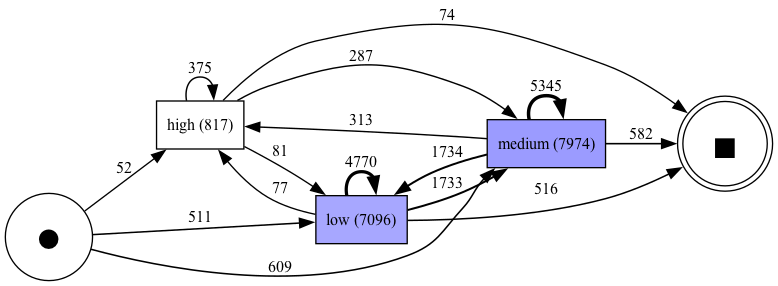

In [52]:
# discover_dfg gibt drei Werte zurück: dfg, start_activities, end_activities
# DFG visualisieren für log_noise
dfg_n, start_n, end_n = pm4py.discover_dfg(log_noise)
pm4py.view_dfg(dfg_n, start_n, end_n)

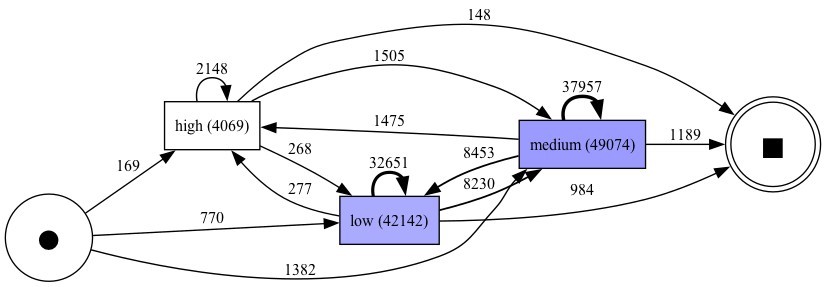

In [53]:
# DFG visualisieren für log_stable
dfg_s, start_s, end_s = pm4py.discover_dfg(log_stable)
pm4py.view_dfg(dfg_s, start_s, end_s)

In [54]:
def calculate_transition_probs(df_log, label):
    # DFG entdecken (Häufigkeiten)
    dfg, start_act, end_act = pm4py.discover_dfg(df_log)

    # Ein Dictionary bauen, um die Summen pro Ausgangszustand zu halten
    totals = {}
    for (source, target), count in dfg.items():
        totals[source] = totals.get(source, 0) + count

    # Wahrscheinlichkeiten berechnen
    probs = []
    for (source, target), count in dfg.items():
        percentage = (count / totals[source]) * 100
        probs.append({
            "Von": source,
            "Nach": target,
            "Wahrscheinlichkeit": round(percentage, 2),
            "Gruppe": label
        })

    return pd.DataFrame(probs)

# Matrizen für beide Gruppen berechnen
matrix_noise = calculate_transition_probs(log_noise, "Lärm-Exponiert")
matrix_stable = calculate_transition_probs(log_stable, "Stabil")

# Zusammenführen für den direkten Vergleich
comparison_df = pd.concat([matrix_noise, matrix_stable])

# Pivot-Tabelle für bessere Lesbarkeit
pivot_comparison = comparison_df.pivot(index=["Von", "Nach"], columns="Gruppe", values="Wahrscheinlichkeit")
print("--- Vergleich der Übergangswahrscheinlichkeiten (%) ---")
print(pivot_comparison)

--- Vergleich der Übergangswahrscheinlichkeiten (%) ---
Gruppe         Lärm-Exponiert  Stabil
Von    Nach                          
high   high             50.47   54.78
       low              10.90    6.83
       medium           38.63   38.38
low    high              1.17    0.67
       low              72.49   79.33
       medium           26.34   20.00
medium high              4.23    3.08
       low              23.46   17.65
       medium           72.31   79.27


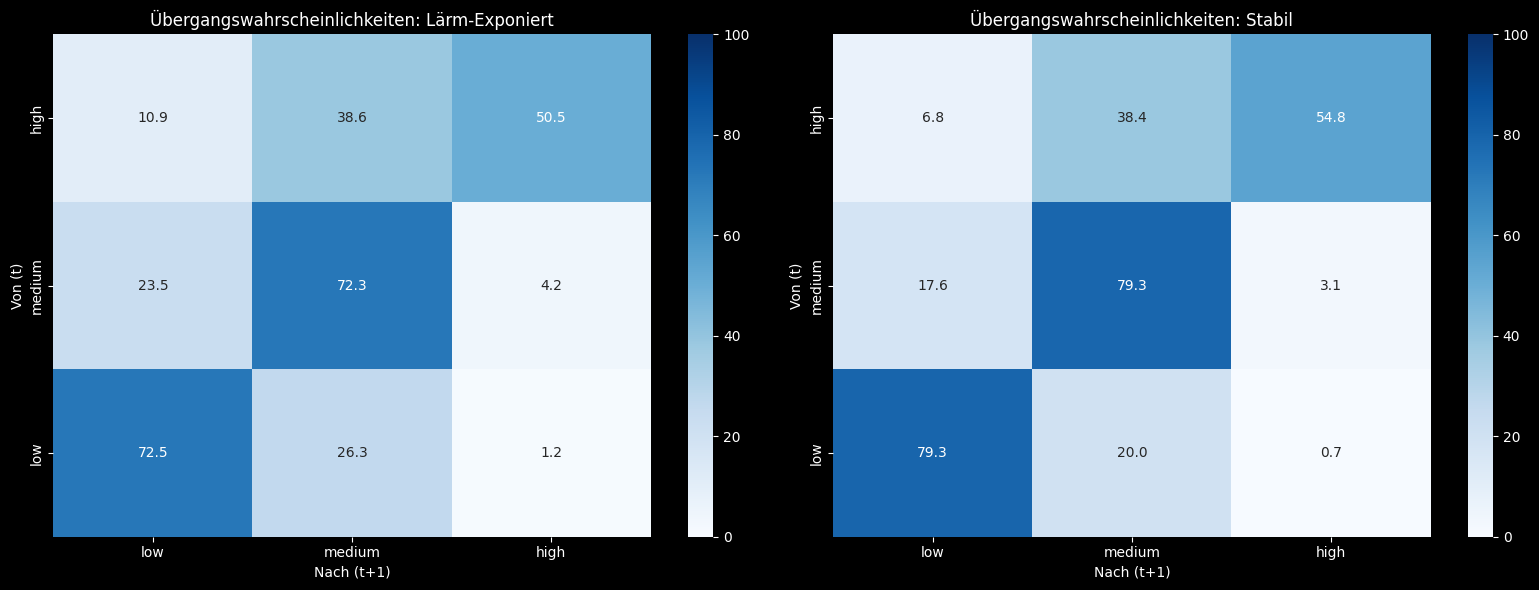

In [55]:
# Heatmap zu dem vorherigen Output

# 1. Daten für die beiden Heatmaps vorbereiten
# Wir extrahieren die Spalten aus deiner pivot_comparison Tabelle
cat_order = ["low", "medium", "high"]
dog_order = ["high", "medium", "low"]

# Erstelle ein Layout mit 2 Spalten
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Liste der Gruppen für die Iteration
gruppen = ["Lärm-Exponiert", "Stabil"]

for i, gruppe in enumerate(gruppen):
    # Daten für die aktuelle Gruppe extrahieren und sortieren
    matrix_data = pivot_comparison[gruppe].unstack(level=1)
    matrix_data = matrix_data.reindex(index=dog_order, columns=cat_order)

    # Heatmap zeichnen
    sns.heatmap(matrix_data, ax=axes[i], annot=True, cmap="Blues",
                vmin=0, vmax=100, fmt=".1f", cbar=True)

    axes[i].set_title(f"Übergangswahrscheinlichkeiten: {gruppe}")
    axes[i].set_xlabel("Nach (t+1)")
    axes[i].set_ylabel("Von (t)")

plt.tight_layout()
plt.show()

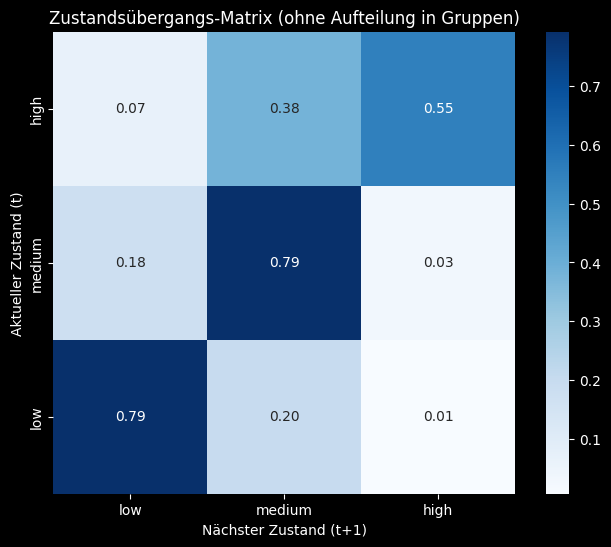

In [56]:
# Heatmap zu den Übergangswahrscheinlichkeiten (ohne Aufteilung in Gruppen)

# 1. Reihenfolge definieren
cat_order = ["low", "medium", "high"]
dog_order = ["high", "medium", "low"]

# 2. Transition-Matrix erstellen und explizit sortieren
transition_df = df.dropna(subset=['concept:name', 'next_concept'])
matrix = pd.crosstab(transition_df['concept:name'], transition_df['next_concept'], normalize='index')
matrix = matrix.reindex(index=dog_order, columns=cat_order)

# 3. Plotten
plt.figure(figsize=(8, 6))
sns.heatmap(matrix, annot=True, cmap="Blues", fmt=".2f", square=True)

plt.title("Zustandsübergangs-Matrix (ohne Aufteilung in Gruppen)")
plt.xlabel("Nächster Zustand (t+1)")
plt.ylabel("Aktueller Zustand (t)")
plt.show()

In [57]:
# SIGNIFIKANZ-TEST (Chi-Quadrat)
# Wir prüfen: Ist der Wechsel von LOW zu MEDIUM abhängig vom Lärm?
# Erstellung einer Kontingenztabelle (Häufigkeitstabelle)
contingency_table = pd.crosstab(df['after_noise_burst'], df['next_concept'])

# Nur relevante Zustände vergleichen (z.B. Wechsel nach Medium)
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print("\n--- Signifikanz-Analyse ---")
print(f"Chi-Quadrat: {chi2:.2f}")  #Je größer dieser Wert ist, desto stärker ist der Hinweis, dass Lärm und der nächste Score-Zustand tatsächlich zusammenhängen.
print(f"p-Wert: {p_value:.4f}")  #p<0.05: Das Ergebnis gilt als signifikant. Du kannst mit 95%iger Sicherheit sagen: Der Lärm hat einen Einfluss.

if p_value < 0.05:
    print("Ergebnis: Statistisch signifikant.")
else:
    print("Ergebnis: Nicht signifikant.")


--- Signifikanz-Analyse ---
Chi-Quadrat: 23.31
p-Wert: 0.0000
Ergebnis: Statistisch signifikant.


In [58]:
# schauen, ob 'frische' vs. 'chronische' Patienten einen Score Anstieg durch Lärm erfahren.
# 1. Median der Onset-Dauer finden
onset_median = df['onset_duration'].median()

# 2. Zwei Sub-Logs erstellen (PM4Py-Format)
log_fresh = get_dfg(df[df['onset_duration'] <= onset_median])
log_chronic = get_dfg(df[df['onset_duration'] > onset_median])

# 3. Den Lärm-Effekt innerhalb dieser Gruppen vergleichen
# (Wir schauen nur auf die Zeilen nach einem Noise-Burst)
fresh_noise_effect = df[(df['onset_duration'] <= onset_median) & (df['after_noise_burst'] == True)]['next_delta_score'].mean()
chronic_noise_effect = df[(df['onset_duration'] > onset_median) & (df['after_noise_burst'] == True)]['next_delta_score'].mean()

print(f"Score-Anstieg nach Lärm bei 'frischen' Fällen: {fresh_noise_effect:.4f}")
print(f"Score-Anstieg nach Lärm bei 'chronischen' Fällen: {chronic_noise_effect:.4f}")

# Positives Ergebnis: Der Lärm führt dazu, dass der Score beim nächsten Mal höher ist. -> Zustand verschlechtert sich.
# Negatives Ergebnis: Der Lärm führt dazu, dass der Score beim nächsten Mal niedriger ist. -> Zustand verbessert sich.

Score-Anstieg nach Lärm bei 'frischen' Fällen: 0.0105
Score-Anstieg nach Lärm bei 'chronischen' Fällen: 0.0087


In [59]:
# Wie viel Prozent der Leute verschlechtern sich?
# Gruppen definieren (Wer hat sich verschlechtert?)
fresh_worsened = df[(df['onset_duration'] <= onset_median) & (df['after_noise_burst'] == True) & (df['next_delta_score'] > 0)]
chronic_worsened = df[(df['onset_duration'] > onset_median) & (df['after_noise_burst'] == True) & (df['next_delta_score'] > 0)]

# 1. Grundgesamtheiten festlegen (Alle Neupatienten mit Lärm / Alle chronischen mit Lärm)
all_fresh_noise = df[(df['onset_duration'] <= onset_median) & (df['after_noise_burst'] == True)]
all_chronic_noise = df[(df['onset_duration'] > onset_median) & (df['after_noise_burst'] == True)]

# 2. Anteil berechnen
percent_fresh = (len(fresh_worsened) / len(all_fresh_noise)) * 100
percent_chronic = (len(chronic_worsened) / len(all_chronic_noise)) * 100

print(f"Anteil der Neupatienten, die sich verschlechtern: {percent_fresh:.2f}%")
print(f"Anteil der chronischen Patienten, die sich verschlechtern: {percent_chronic:.2f}%")

Anteil der Neupatienten, die sich verschlechtern: 41.93%
Anteil der chronischen Patienten, die sich verschlechtern: 38.40%


In [60]:
# Ist Lärm für alle gleich schlecht? - Ereignis Analyse
# Nur Lärm-Ereignisse betrachten
noise_events = df[df['after_noise_burst'] == True].copy()

# Verlierer: Score steigt nach Lärm (Verschlechterung)
verlierer = noise_events[noise_events['next_delta_score'] > 0]

# Gewinner: Score sinkt nach Lärm (Verbesserung/Maskierung)
gewinner = noise_events[noise_events['next_delta_score'] < 0]

# Neutrale: Score bleibt gleich (resilient)
neutrale = noise_events[noise_events['next_delta_score'] == 0]

print(f"--- Lärm-Reaktions-Profil (N={len(noise_events)}) ---")
print(f"Verlierer (Sensibel): {len(verlierer)} Fälle ({len(verlierer)/len(noise_events)*100:.1f}%)")
print(f"Gewinner (Maskierung): {len(gewinner)} Fälle ({len(gewinner)/len(noise_events)*100:.1f}%)")
print(f"Neutrale: {len(neutrale)} Fälle ({len(neutrale)/len(noise_events)*100:.1f}%)")

# Durchschnittliche Stärke der Reaktion
print(f"Durchschn. Verschlechterung bei Verlierern: +{verlierer['next_delta_score'].mean():.2f} Punkte")
print(f"Durchschn. Verbesserung bei Gewinnern: {gewinner['next_delta_score'].mean():.2f} Punkte")

--- Lärm-Reaktions-Profil (N=15887) ---
Verlierer (Sensibel): 6445 Fälle (40.6%)
Gewinner (Maskierung): 6610 Fälle (41.6%)
Neutrale: 2475 Fälle (15.6%)
Durchschn. Verschlechterung bei Verlierern: +5.26 Punkte
Durchschn. Verbesserung bei Gewinnern: -5.10 Punkte


In [61]:
# zum obigen Output: --> Lärm hat eine extrem polarisierende Wirkung. Lärm löst starke Schwankungen im Patientenzustand aus.

In [62]:
# Ist Lärm für alle gleich schlecht? - Personen Analyse
# 1. Wir berechnen pro User die mittlere Reaktion auf Lärm-Events
user_noise_reaction = df[df['after_noise_burst'] == True].groupby('user_id').agg({
    'next_delta_score': 'mean',
    'onset_duration': 'first', # Die Dauer bleibt für den User ja (fast) gleich
    'age': 'first'
}).reset_index()

# 2. Jetzt erst teilen wir die 3.339 USER in Typen ein
user_verlierer = user_noise_reaction[user_noise_reaction['next_delta_score'] > 0]
user_gewinner = user_noise_reaction[user_noise_reaction['next_delta_score'] < 0]
user_stabil = user_noise_reaction[user_noise_reaction['next_delta_score'] == 0]

print(f"--- USER-TYPOLOGIE (N = {user_noise_reaction['user_id'].nunique()} User) ---")
print(f"Sensible User: {len(user_verlierer)} ({len(user_verlierer)/len(user_noise_reaction)*100:.1f}%)")
print(f"Maskierer/Resiliente: {len(user_gewinner)} ({len(user_gewinner)/len(user_noise_reaction)*100:.1f}%)")
print(f"Stabile User: {len(user_stabil)} ({len(user_stabil)/len(user_noise_reaction)*100:.1f}%)")

# 3. Signifikanz-Check auf USER-Ebene (Nicht Event-Ebene)
t_stat, p_val = ttest_ind(user_verlierer['onset_duration'].dropna(),
                          user_gewinner['onset_duration'].dropna())

print(f"\nSignifikanz des Onset-Unterschieds zwischen den User-Typen: p = {p_val:.4f}")

--- USER-TYPOLOGIE (N = 1172 User) ---
Sensible User: 491 (41.9%)
Maskierer/Resiliente: 498 (42.5%)
Stabile User: 56 (4.8%)

Signifikanz des Onset-Unterschieds zwischen den User-Typen: p = 0.2346


In [63]:
# User schrumpfen von 2321 auf 1172, da nur 1172 einem Noise Burst ausgesetzt waren. Die Anderen nicht.
# p=0.2346 --> Die Dauer der Erkrankung (ob 5 oder 15 Jahre) hat absolut keinen Einfluss darauf, ob jemand auf Lärm sensibel oder mit Maskierung reagiert.

#### Schauen, wie sich Onset_duration auf Score auswirkt. --> Ergebnisse sind Quatsch

In [64]:
# 1. Datensatz der Lärm-Ereignisse vorbereiten
noise_events = df[df['after_noise_burst'] == True].copy()

# 2. Gruppen definieren
verlierer = noise_events[noise_events['next_delta_score'] > 0]
gewinner = noise_events[noise_events['next_delta_score'] < 0]

print(f"--- Profil-Vergleich (Lärm-Reaktion) ---")
print(f"Verlierer (N={len(verlierer)}): Mittlere Onset-Dauer = {verlierer['onset_duration'].mean():.1f} Jahre")
print(f"Gewinner  (N={len(gewinner)}): Mittlere Onset-Dauer = {gewinner['onset_duration'].mean():.1f} Jahre")

# 3. Statistischer Check: Ist der Unterschied in der Dauer signifikant?
t_stat, p_val = ttest_ind(verlierer['onset_duration'].dropna(), gewinner['onset_duration'].dropna())
print(f"Signifikanz des Onset-Unterschieds: p = {p_val:.4f}")

--- Profil-Vergleich (Lärm-Reaktion) ---
Verlierer (N=6445): Mittlere Onset-Dauer = 9.4 Jahre
Gewinner  (N=6610): Mittlere Onset-Dauer = 9.3 Jahre
Signifikanz des Onset-Unterschieds: p = 0.8767


In [65]:
4487+4619

9106

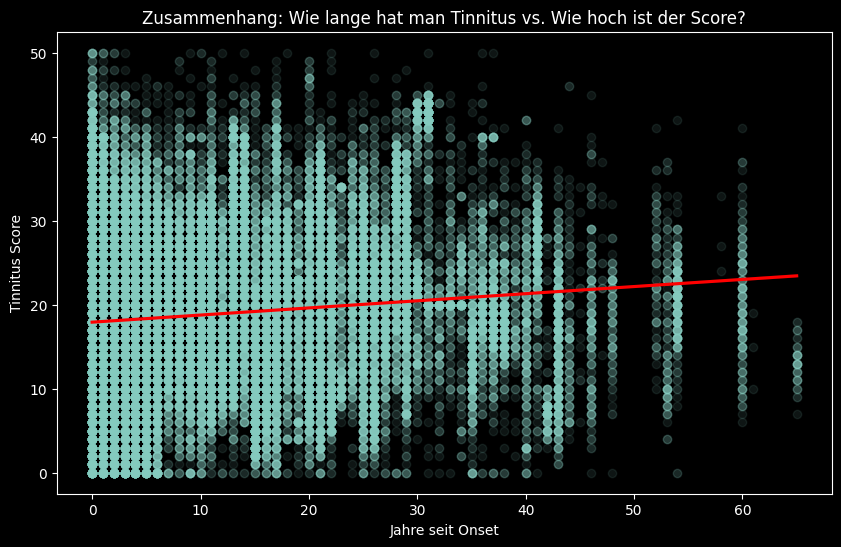

In [66]:
# Visualisierung des Trends
plt.figure(figsize=(10, 6))
sns.regplot(data=df[df['onset_duration'] <= 65], x='onset_duration', y='score', scatter_kws={'alpha':0.1}, line_kws={'color':'red'})
plt.title("Zusammenhang: Wie lange hat man Tinnitus vs. Wie hoch ist der Score?")
plt.xlabel("Jahre seit Onset")
plt.ylabel("Tinnitus Score")
plt.show()

In [67]:
print(df[df['onset_duration'] > 65].shape)

(172, 39)


In [68]:
# Wir gruppieren die Onset-Dauer in Kategorien, um den Trend zu sehen
def duration_group(days):
    if days <= 7: return "1. Woche (Akut)"
    if days <= 30: return "1. Monat (Subakut)"
    if days <= 180: return "Halbes Jahr"
    if days <= 365: return "1 Jahr"
    else: return "Chronisch (>1 Jahr)"

df['duration_cat'] = df['onset_duration'].apply(duration_group)

# Durchschnitts-Score je Dauer-Kategorie
habituation_profile = df.groupby('duration_cat')['score'].mean().sort_values(ascending=False)

print("--- Habituation: Sinkt die Belastung mit der Zeit? ---")
print(habituation_profile)

--- Habituation: Sinkt die Belastung mit der Zeit? ---
duration_cat
Halbes Jahr            20.332749
1. Monat (Subakut)     19.993472
Chronisch (>1 Jahr)    17.931728
1. Woche (Akut)        17.807269
Name: score, dtype: float64


# df auf PM4Py Analyse vorbereiten

In [69]:
# Case = Patient
df_event = df.rename(columns={
    "user_id": "case:concept:name",
    "created_at": "time:timestamp"
})

# Datentypen fixen
df_event["case:concept:name"] = df_event["case:concept:name"].astype(str)
df_event["concept:name"] = df_event["concept:name"].astype(str)

# Datentypen Kontrollieren
print(df_event["case:concept:name"].dtype)
print(df_event["concept:name"].dtype)

# Sortieren nach Zeit
df_event = df_event.sort_values(
    by=["case:concept:name", "time:timestamp"]
)

# Relevante Spalten behalten
df_event = df_event[[
    "case:concept:name",
    "concept:name",
    "time:timestamp",
    "age",
    "gender",
    "sound_norm", #ursprünglich war hier "sound_env". jetzt haben wir aber die Werte selbst umgewandelt
    "after_noise_burst"
]]

df_event

str
str


,case:concept:name,concept:name,time:timestamp,age,gender,sound_norm,after_noise_burst
13122,1000,medium,2015-04-14 13:43:00,38.0,0.0,-0.490312,False
13123,1000,low,2015-04-14 21:16:00,38.0,0.0,-0.482998,False
13124,1000,low,2015-04-15 09:39:00,38.0,0.0,-0.475365,False
13125,1000,low,2015-04-15 13:16:00,38.0,0.0,-0.483952,False
13126,1000,low,2015-04-20 21:09:00,38.0,0.0,-0.492220,False
...,...,...,...,...,...,...,...
13115,996,high,2015-04-09 06:04:00,48.0,0.0,-1.063784,False
13116,997,medium,2015-04-08 22:55:00,30.0,0.0,-1.748773,False
13117,997,medium,2015-04-09 07:17:00,30.0,0.0,-1.624863,False
13118,997,low,2015-04-09 16:48:00,30.0,0.0,-0.418933,False


In [70]:
# Personen je Level
df_event.groupby("concept:name")["case:concept:name"].nunique()

concept:name
high       604
low       1774
medium    2039
Name: case:concept:name, dtype: int64

In [71]:
# Traces je Level
df_event.groupby("concept:name")["concept:name"].count()

concept:name
high       4886
low       49238
medium    57048
Name: concept:name, dtype: int64

In [72]:
df_event[df_event["time:timestamp"].isna()]

,case:concept:name,concept:name,time:timestamp,age,gender,sound_norm,after_noise_burst


In [73]:
# Kontrollieren, dass jetzt die Sortierung nach Case und timestamp sortiert ist
df_event.head(20)

,case:concept:name,concept:name,time:timestamp,age,gender,sound_norm,after_noise_burst
13122,1000,medium,2015-04-14 13:43:00,38.0,0.0,-0.490312,False
13123,1000,low,2015-04-14 21:16:00,38.0,0.0,-0.482998,False
13124,1000,low,2015-04-15 09:39:00,38.0,0.0,-0.475365,False
13125,1000,low,2015-04-15 13:16:00,38.0,0.0,-0.483952,False
13126,1000,low,2015-04-20 21:09:00,38.0,0.0,-0.492220,False
13127,1000,low,2015-04-25 22:19:00,38.0,0.0,-0.488086,False
13128,1000,low,2015-05-06 11:54:00,38.0,0.0,-0.483316,False
13129,1000,low,2015-07-14 12:00:00,39.0,0.0,1.343047,False
13130,1000,low,2015-07-14 12:00:00,39.0,0.0,-0.464235,True
13131,1000,low,2015-12-15 19:45:00,39.0,0.0,-0.477274,False


## Noise Reduzierung

In [74]:
# Täglich zusammenfassen (User mit mehreren Einträgen an einem Tag werden auf einen Eintrag am Tag reduziert.)
df_daily = df.groupby(['user_id', pd.Grouper(key='created_at', freq='D')]).agg({
    'concept:name': 'last',          # Zustand am Ende des Tages
    'sound_norm': 'mean',            # Durchschnittliche Lärmbelastung
    'age': 'first',                  # Alter (bleibt gleich)
    'gender': 'first',               # Geschlecht (bleibt gleich)
    'after_noise_burst': 'max'       # 'max' auf Boolean ist True, wenn mind. ein Event True war
}).reset_index()

# Spalten für PM4Py/df_event Kompatibilität umbenennen
df_daily = df_daily.rename(columns={
    'created_at': 'time:timestamp',
    'user_id': 'case:concept:name'
})

# Reihenfolge der Spalten exakt wie in df_event
df_daily = df_daily[[
    "case:concept:name",
    "concept:name",
    "time:timestamp",
    "age",
    "gender",
    "sound_norm",
    "after_noise_burst"
]]

--- Vergleich: Rohdaten vs. Aggregiert (Täglich) ---
Anzahl Traces (Roh): 2321 | (Aggregiert): 2321
Anzahl Events (Roh): 111172 | (Aggregiert): 46474

Insgesamt um 64698 Events reduziert.

DFG der Rohdaten:


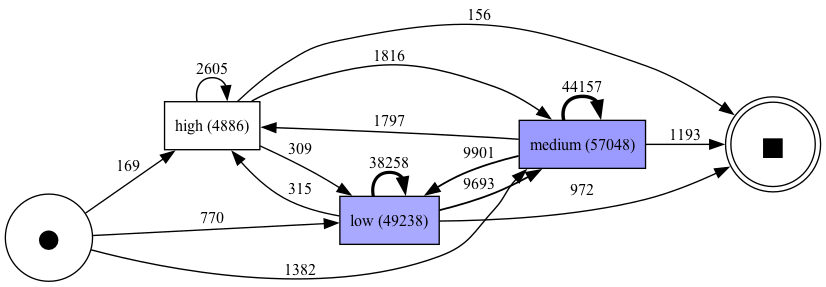


DFG der aggregierten Daten:


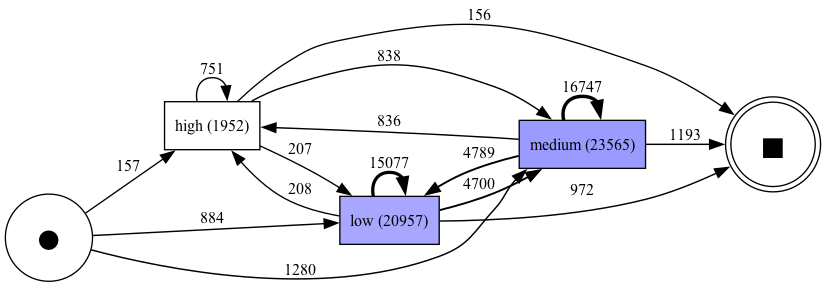

In [75]:
# Versuch zu schauen, ob mehrere Einträge an einem Tag einer Person auf einen zusammengefasst werden kann und sollte (mit Vergleich zum normalen Log).

# 1. Vorbereitung der Logs für den Vergleich
df_daily_ready = df_daily.copy()
df_daily_ready['case:concept:name'] = df_daily_ready['case:concept:name'].astype(str)
df_daily_ready['concept:name'] = df_daily_ready['concept:name'].astype(str)

if not pd.api.types.is_datetime64_any_dtype(df_daily_ready['time:timestamp']):
    df_daily_ready['time:timestamp'] = pd.to_datetime(df_daily_ready['time:timestamp'])

# Jetzt konvertieren
log_raw = pm4py.convert_to_event_log(df_event)
log_daily = pm4py.convert_to_event_log(df_daily_ready)

# 2. Vergleich der Anzahl der Logs (Traces und Events)
print("--- Vergleich: Rohdaten vs. Aggregiert (Täglich) ---")
print(f"Anzahl Traces (Roh): {len(log_raw)} | (Aggregiert): {len(log_daily)}")
print(f"Anzahl Events (Roh): {sum(len(t) for t in log_raw)} | (Aggregiert): {sum(len(t) for t in log_daily)}")
print(f"\nInsgesamt um {(sum(len(t) for t in log_raw))-(sum(len(t) for t in log_daily))} Events reduziert.")

# 3. DFG Discovery
dfg_raw, start_raw, end_raw = pm4py.discover_dfg(log_raw)
dfg_daily, start_daily, end_daily = pm4py.discover_dfg(log_daily)

# 4. Visualisierung der Unterschiede
# DFG Rohdaten
print("\nDFG der Rohdaten:")
pm4py.view_dfg(dfg_raw, start_raw, end_raw)

# DFG aggregierte Daten
print("\nDFG der aggregierten Daten:")
pm4py.view_dfg(dfg_daily, start_daily, end_daily)

In [76]:
# Prozess-Mining dient dazu, die großen Pfade und Trends zu visualisieren (Macro-Level).
# Die statistischen Modelle (Random Forest) dienen dazu, Kausalzusammenhänge zu finden (Micro-Level).
# Beide Welten durch den Vergleich der Ergebnisse (z. B. "Der Effekt X, den wir in der Statistik sehen, spiegelt sich im aggregierten Prozess-Modell durch den Pfad Y wider") validieren.

## Logs für Export erstellen

In [77]:
# 1. Berechnung der Varianten-Häufigkeit
log = pm4py.convert_to_event_log(df_event)
variants = pm4py.get_variants(log)

# Konvertiere die Tupel (Aktivitäten) in eine lesbare String-Repräsentation
variant_list = [", ".join(v) for v in variants.keys()]
variant_counts = [len(v) for v in variants.values()]

# DataFrame erstellen
variant_df = pd.DataFrame({'variant': variant_list, 'count': variant_counts})

# Sortieren
variant_df = variant_df.sort_values(by='count', ascending=False).reset_index(drop=True)

# Kumulative Prozent berechnen
variant_df['cumulative_percent'] = variant_df['count'].cumsum() / variant_df['count'].sum()

# Grenze bei 80% finden
top_k_80 = variant_df[variant_df['cumulative_percent'] <= 0.80].shape[0]
print(f"Die Top {top_k_80} Varianten decken 80% aller Fälle ab.")

# Top 80% bzw. 100/x/1000 Einträge holen
filtered_log = pm4py.filter_variants_top_k(log, k=top_k_80) # Wert entsprechend eintragen

print(f"\nUrsprüngliche Anzahl Traces: {len(log)}")
print(f"Anzahl Traces nach Filterung (Top {top_k_80} Varianten): {len(filtered_log)}")

Die Top 832 Varianten decken 80% aller Fälle ab.

Ursprüngliche Anzahl Traces: 2321
Anzahl Traces nach Filterung (Top 832 Varianten): 1856


## Export

In [78]:
'''
# euren gewünschten Pfad hernehmen. Dann auch hernehmen, um damit weiter zu arbeiten.

pm4py.write_xes(log, '/Users/elias/Desktop/Uni/4. Semester : Masterarbeit/2026-04-06 TYT_event_log V2.0.xes')
pm4py.write_xes(log_daily, '/Users/elias/Desktop/Uni/4. Semester : Masterarbeit/2026-04-06 TYT_event_log V2.0 daily.xes')
pm4py.write_xes(filtered_log, '/Users/elias/Desktop/Uni/4. Semester : Masterarbeit/2026-04-06 TYT_event_log V2.0 filtered.xes')
'''

/Users/elias/PycharmProjects/MasterArbeit/.venv/lib/python3.12/site-packages/pm4py/utils.py:1025: UserWarning: Install the optional requirement `r4pm` to import/export files faster. `rustxes` remains supported as a fallback.
  warnings.warn(
/Users/elias/PycharmProjects/MasterArbeit/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
exporting log, completed traces :: 100%|██████████| 1856/1856 [00:01<00:00, 1806.76it/s]
